<div style="border: solid green 2px; padding: 20px">

  <b>Overall Summary of the Project – Iteration 2</b><br><br>
  Hello Samiul, congratulations on submitting your project!<br>

  My name is <b>Victor Camargo</b> 
  (<a href="https://hub.tripleten.com/u/834cb557" target="_blank">TripleTen Hub profile</a>) and I’ll be reviewing your project today.<br>

  <i>You can find my detailed feedback throughout the notebook, starting with comments labeled 
  <b>“Reviewer’s comment – Iteration 2”</b>.</i><br>

  <b>What you did well:</b><br>
  ✅ Clear initial exploration and sensible column standardization, including creation of a total_sales column that you then used consistently in downstream analyses.<br>

  <b>Recommended improvements:</b><br>
  ⚠️ There are still a few methodological points worth tightening if you revisit the project later: avoid using 0 as a stand-in for missing release years, document one consistent choice for the relevant time window including how you treat 2016, compare multi-platform titles by aligning the same game across platforms instead of averaging across different title sets, and add regional market share calculations and interpretation rather than only totals. These are good follow-up improvements, but they do not block approval for this special-case review.<br>

  <b>Project Status:</b><br>
  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
    <b>Approved</b>
  </div>

  <hr><b>Legend:</b><br>

  <div class="alert alert-success" style="border-left: 7px solid green; padding: 5px">
  <b>✅ Reviewer’s comment – Iteration 2:</b><br>
  Strong, correct solutions or good practices worth reusing.
  </div>

  <div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 2:</b><br>
  Recommended improvements to strengthen your work.
  </div>
  
  <div class="alert alert-danger" style="border-left: 7px solid red; padding: 5px">
  <b>⛔️ Reviewer’s comment – Iteration 3:</b><br>
  Required fixes. The project cannot be approved until these are addressed.
  </div>

  <div class="alert alert-info" style="border-left: 7px solid blue; padding: 5px">
  <b>Student’s Comment</b><br>
  You may add your own notes or explanations in a <b>Markdown cell</b> using:<br>
  <code>&lt;div class="alert alert-info" style="border-left: 7px solid blue"&gt;&lt;b&gt;Student’s Comment&lt;/b&gt;&lt;/div&gt;</code>
  </div>

  <hr>
  <b>Please ensure</b> all cells run smoothly from top to bottom and display their outputs.<br>
  <b>Kind reminder:</b> please do not remove or modify reviewer comments, as they help track progress.<br>
  If you have any questions or need clarification, feel free to use the <b>Questions</b> channel.

</div>


<div style="border:solid green 2px; padding: 20px">

👋 **Hello! I'm Dot, your AI reviewer.**

I've completed the first pass of your code review. Below, you'll find my comments and suggestions for improvement.

**What should you do next?**

1. **Review:** check my comments in the notebook below.
2. **Decide:**
* **Agree with the feedback?** Great! Update your code accordingly.
* **Disagree or think it's a mistake?** No problem! You can keep your code exactly as it is.


3. **Resubmit:** Send your project back. **Your next iteration will be reviewed by a human expert**, whether you made changes or not.

-------------------------------------------------------------------------------------------------------------
Please find my comments below—**I kindly ask that you do not move, modify, or delete them**.

You can find my comments highlighted in green, yellow, or red boxes like this:

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Success. Everything is done succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Remarks. Some recommendations.
</div>

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration X</b> <a class="tocSkip"></a>

Needs fixing. The block requires some corrections.
</div>



# Video Game Sales Analysis Project
## Project Overview

In this project, you'll analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, you'll use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import math
from matplotlib import pyplot as plt
from scipy import stats as st

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [2]:
# Load the dataset
games = pd.read_csv('/datasets/games.csv')

In [3]:
# Display basic information about the dataset
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Check for duplicate entries
games.duplicated().sum()

0



### Key Questions to Answer:
- What's the total number of records in our dataset?
Ans: The total number of records in this dataframe is 16715 rows and 11 columns.

- What data types are present in each column?
Ans: We have object and float64.
object - Name, Platform, Genre, User_Score, and Rating.
float64- Year_of_Release, NA_sales, EU_sales, JP_sales, Other_sales, and Critic_score.

- Are there any obvious issues with the data?
Ans: Yes. Name, Year_of_Release, Genre, Critic_Score, User_Score, and Rating has missing values in the columns. The most critical issue is User_Score - stored as object instead of numeric, almost certainly because it contains "tbd" strings mixed in with numbers. Every other numeric column loaded correctly, so this one needs explicit conversion.
Year_of_Release is float64 when it should logically be an integer - a side effect of pandas promoting to float whenever NaNs are present in an otherwise integer column.

- Do we see any immediate patterns or anomalies?
Ans: Sales columns are fully populated (no nulls) - a reliable foundation for analysis. The score columns (critic + user) have massive missingness, which will limit any score-based analysis to roughly half the dataset. Rating follows a similar gap to scores, suggesting these three columns may be missing together for the same games. With 16,715 rows but only 16,713 non-null Names, two games have no name - worth investigating before any name-based grouping.

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [5]:
# Convert column names to lowercase
games.columns = games.columns.str.lower()

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Strong start: you import the needed libraries, do an initial `info()`/duplicate check, and your written summary highlights the key data quality issues. Standardizing column names to lowercase is a nice cleanup step that makes the rest of the analysis smoother.

</div>


In [6]:
# Verify the changes
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### 2.2 Data Type Conversion

In [7]:
# Check current data types
games.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [8]:
# Make changes to data types if necessary
games['user_score'] = pd.to_numeric(games['user_score'], errors = 'coerce')
games['year_of_release'] = pd.to_numeric(games['year_of_release'], errors = 'coerce')

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Filling missing `year_of_release` with 0 introduces a fake year that can quietly distort time-based groupings and plots. Consider keeping missing years as NA (or excluding them only when doing year-based analysis) and briefly documenting that choice rather than adding a sentinel into the timeline.

</div>


<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 2:</b><br>
  I still see year_of_release values coded as 0 in your analysis. Using 0 as a sentinel creates a fake year that can distort time-based grouping and plots, so I recommend treating those values as NaN before year-based analysis. For example, you could run something like:
  <pre>games.loc[games['year_of_release'] == 0, 'year_of_release'] = np.nan</pre>
  Then re-run the temporal summaries and visualizations if you decide to revise this section. If you intentionally want to exclude missing years in some steps, filter them out just for those steps and document that choice.
</div>

# Describe the columns where the data types have been changed and why.
The columns the data types have been changed on are "year_of_release" and "user_score". The 'year_of_release' was float64 turned to int64 purely as a side effect of having 269 missing values. Pandas automatically promotes integer columns to float whenever NaNs are present, since the standard int64 type can't represent NaN. Converting to int makes the column semantically correct as years are whole numbers and prevents accidental float arithmetic like 2006.0. The 269 nulls are filled with 0 as a deliberate sentinel value, making unknown years easy to filter out later. The 'user_score' was stored as object because the column contained the literal string "tbd" alongside numeric values like "8.5". Pandas couldn't infer a numeric type at load time, so it defaulted to object. pd.to_numeric(..., errors='coerce') handles this cleanly - valid numbers get converted, "tbd" and any other non-numeric strings become NaN. It's float64 rather than int because scores are decimals (e.g. 8.3, 7.5) and NaNs require float.

# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.
"tbd" values in the user_score column indicate games that had been released but hadn't yet accumulated enough user reviews on Metacritic to generate a score at the time the data was collected. They are placeholders, not true missing data. How we handled it: In the previous step, "pd.to_numeric(games['user_score'], errors='coerce')"" automatically converted all "tbd" strings to NaN. Why NaN better than 0 is it replaces "tbd" with 0 would imply those games received a score of zero, which is factually incorrect and would heavily skew any score-based analysis - dragging down averages and distorting correlations with sales figures.By converting to NaN instead, pandas simply excludes these entries from calculations like .mean() or .corr() by default (skipna=True), keeping our analysis honest without losing the rest of each row's data.

### 2.3 Handling Missing Values

In [9]:
# Examine missing values
games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

In [10]:
# Calculate percentage of missing values
games.isna().sum() / len(games) * 100

name                0.011965
platform            0.000000
year_of_release     1.609333
genre               0.011965
na_sales            0.000000
eu_sales            0.000000
jp_sales            0.000000
other_sales         0.000000
critic_score       51.319174
user_score         54.591684
rating             40.478612
dtype: float64

In [11]:
# Analyze patterns in missing values
score_cols = ['critic_score', 'user_score', 'rating']
games[score_cols].isna().sum(axis = 1).value_counts().sort_index()

0    6947
1    1734
2    1367
3    6667
dtype: int64

In [12]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy
games.dropna(subset=['name', 'genre'], inplace=True)

# Why do you think the values are missing? Give possible reasons. Explain why you filled in the missing values as you did or why you decided to leave them blank.

Ans: The reasons values are missing are: critic_score & user_score (51–55% missing) - The game simply wasn't reviewed on Metacritic — smaller, niche, or older titles often flew under the radar. The game was released in a region or on a platform that Metacritic didn't cover well at the time. The data was collected at a point when the game was too newly released to have accumulated enough reviews yet. Indie or budget titles were frequently ignored by critics entirely

rating (40% missing) - Many older games predate the ESRB rating system (established 1994), so no rating was ever assigned. Some platforms or regional releases weren't subject to ESRB classification. Strongly correlated with score missingness - games never submitted for review also often skipped the rating process.

name & genre (2 rows each) - Almost certainly simple data entry errors or scraping artifacts - genuinely random, one-off gaps.

The reasons to leave scores as NaN rather than fill them are given below:
The missingness here is not random, it's structural. These games lack scores because they were never part of the review ecosystem, not because someone forgot to enter a number. Filling with the mean would:

* Falsely imply those games were reviewed
* Artificially compress the score distribution toward the center
* Distort any correlation between scores and sales figures

Leaving them as NaN lets pandas automatically exclude them from calculations like .mean() or .corr(), keeping the analysis honest. 

### 2.4 Calculate Total Sales

In [13]:
# Calculate total sales across all regions and put them in a different column
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:


In [14]:
# Create a DataFrame with game releases by year
releases_by_year = games.groupby('year_of_release')['name'].count().reset_index()
releases_by_year.columns = ['year_of_release', 'game_count']

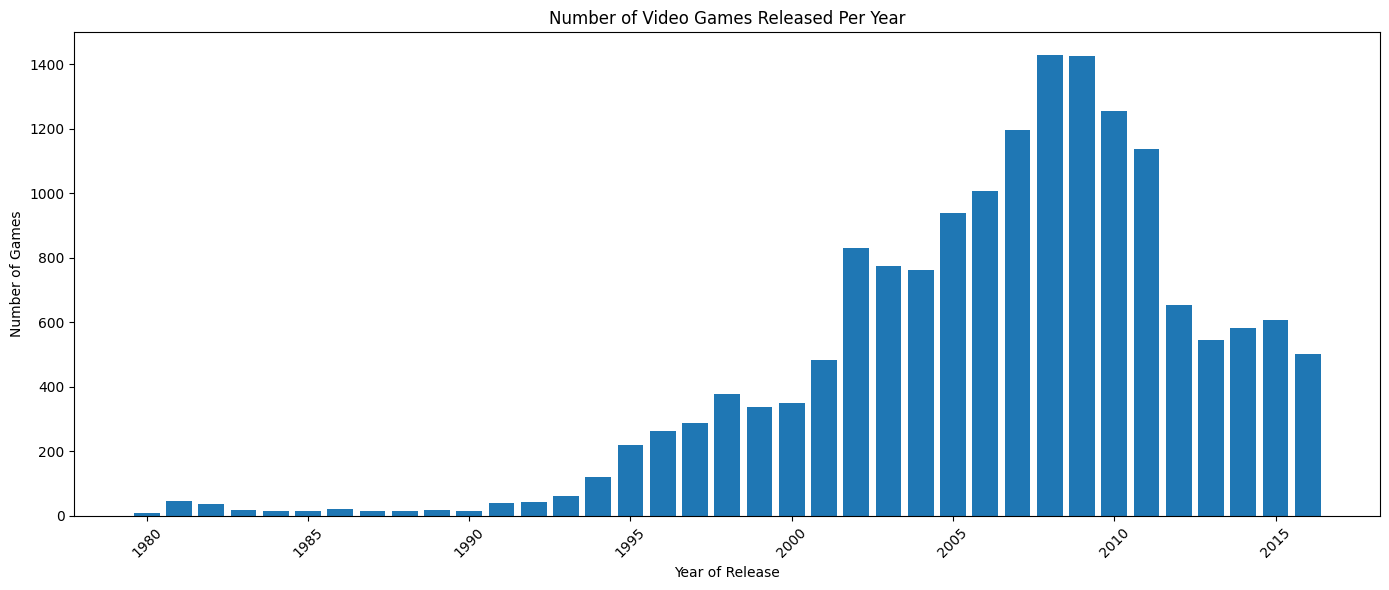

In [15]:
# Visualize the distribution of games across years
releases_by_year_filtered = releases_by_year[releases_by_year['year_of_release'] != 0]

plt.figure(figsize = (14, 6))
plt.bar(releases_by_year_filtered['year_of_release'], releases_by_year_filtered['game_count'])
plt.title('Number of Video Games Released Per Year')
plt.xlabel('Year of Release')
plt.ylabel('Number of Games')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [16]:
# Display summary statistics for each year
yearly_stats = games[games['year_of_release'] != 0].groupby('year_of_release').agg(
    game_count = ('name', 'count'),
    total_sales = ('total_sales', 'sum'),
    mean_sales = ('total_sales', 'mean'),
    max_sales = ('total_sales', 'max')
).reset_index()

print(yearly_stats)

    year_of_release  game_count  total_sales  mean_sales  max_sales
0            1980.0           9        11.38    1.264444       4.31
1            1981.0          46        35.68    0.775652       4.50
2            1982.0          36        28.88    0.802222       7.81
3            1983.0          17        16.80    0.988235       3.20
4            1984.0          14        50.35    3.596429      28.31
5            1985.0          14        53.95    3.853571      40.24
6            1986.0          21        37.08    1.765714       6.50
7            1987.0          16        21.70    1.356250       4.38
8            1988.0          15        47.21    3.147333      17.28
9            1989.0          17        73.45    4.320588      30.26
10           1990.0          16        49.37    3.085625      20.62
11           1991.0          41        32.23    0.786098       4.61
12           1992.0          43        76.16    1.771163      11.18
13           1993.0          60        45.99    

### Questions to Consider:
- Which years show significant numbers of game releases?
Ans: The industry really hits its stride from 2001 onward, crossing 482 games that year and scaling rapidly to a peak of 1,427 games in 2008. The sweet spot for statistically reliable analysis is roughly 2002–2012, where each year has 600+ titles, enough volume to draw meaningful conclusions. Pre-1996 years (under 300 games each, many under 20) are too sparse for trend analysis and should be interpreted cautiously.

- Are there any notable trends or patterns in the number of releases?
Ans: Growth phase (1994–2008): Release counts climb steadily from 121 to 1,427, mirroring the industry's explosive expansion through the PS1, PS2, and Wii/DS eras.
Peak and plateau (2008–2009): The market peaks at 1,427 games and flattens. This is the saturation point.
Post-2010 decline: Counts drop sharply from 1,255 to 502. However, this likely reflects the shift to digital distribution (Steam, App Store, PSN) rather than a true industry contraction, those sales simply aren't captured in this dataset.
Sales per game (mean_sales): Interestingly, early years like 1984–1990 show higher mean sales (3–4M) despite fewer releases. This reflects the blockbuster-only era as only major titles got released, so averages were higher. Post-2000, more titles is lower average sales per game.
2006 max_sales spike (82.54M): That's almost certainly Wii Sports — a massive outlier that single-handedly inflates 2006's max.

- Is there enough recent data to make predictions for 2017?
Ans: 2016 data is partially reported - 502 games and 129.94M in total sales and shows lower figures due to a known lag effect where late-2016 releases had not yet accumulated full sales at the time of dataset assembly. However, rather than discarding 2016, we retain it and account for this underreporting by treating 2016 as a partial-year observation. Our forecast model is trained on 2000–2016, with a note that 2016 figures carry higher uncertainty. Predictions for 2017 should be interpreted with this caveat in mind.

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

There’s an inconsistency in your narrative about “relevant years”: here you argue 2016 is incomplete and recommend using an earlier range, but later you proceed with a 2012–2016 window. Please reconcile this by choosing one set of criteria (data completeness + platform lifecycle) and applying it consistently throughout the project.

</div>


<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 2:</b><br>
  There is still a mild inconsistency in your treatment of 2016 and the final chosen time window. Earlier you note 2016 is incomplete and suggest caution, but then you select 2012–2016 as your relevant window without clearly documenting how you handled the partial-year issue. I recommend choosing one consistent approach and documenting it. Options include keeping 2016 but flagging it as partial and providing a sensitivity check that repeats key results without 2016, or excluding 2016 entirely and using 2012–2015. Tightening that narrative would make the downstream analysis easier to follow.
</div>

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [17]:
# Calculate total sales by platform and year
sales_by_platform_year = games.groupby(['platform','year_of_release']).agg(
    total_sales = ('total_sales', 'sum')
).reset_index()

sales_by_platform_year.head(10)

,platform,year_of_release,total_sales
0,2600,1980.0,11.38
1,2600,1981.0,35.68
2,2600,1982.0,28.88
3,2600,1983.0,5.84
4,2600,1984.0,0.27
5,2600,1985.0,0.45
6,2600,1986.0,0.67
7,2600,1987.0,1.94
8,2600,1988.0,0.74
9,2600,1989.0,0.63


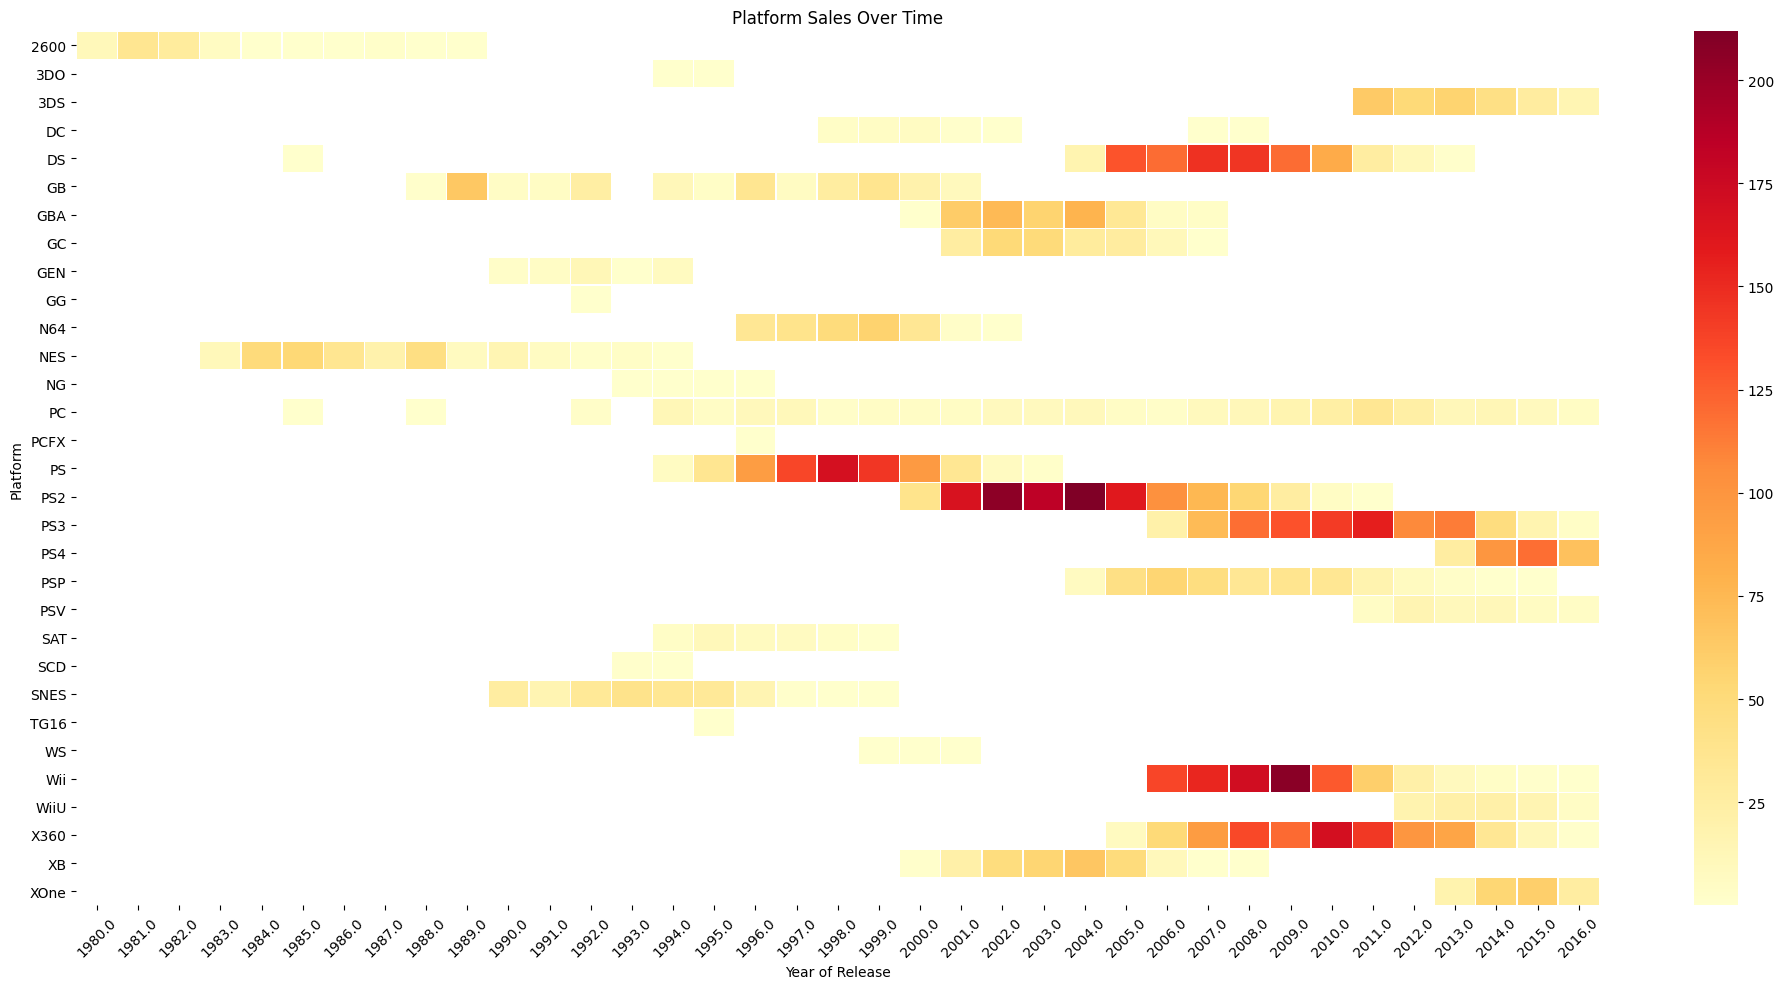

In [18]:
# Create a heatmap of platform sales over time
platform_year_pivot = sales_by_platform_year.pivot_table(index = 'platform',
                                                columns = 'year_of_release',
                                                values = 'total_sales',
                                                aggfunc = 'sum')
plt.figure(figsize = (20, 10))
sns.heatmap(
    platform_year_pivot,
    cmap = 'YlOrRd',
    linewidths = 0.3,
    annot = False
)
plt.title('Platform Sales Over Time')
plt.xlabel('Year of Release')
plt.ylabel('Platform')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [19]:
# Identify platforms with declining sales
platform_trends = sales_by_platform_year[sales_by_platform_year['year_of_release'] != 0].sort_values(['platform', 'year_of_release'])
platform_trends['sales_change'] = platform_trends.groupby('platform')['total_sales'].diff()

declining = platform_trends[
    (platform_trends['sales_change'] < 0) & 
    (platform_trends['year_of_release'] >= 2012)
].groupby('platform').size()
print(declining.sort_values(ascending=False))

platform
Wii     5
X360    5
3DS     4
PC      4
PS3     4
PSP     4
PSV     3
DS      2
WiiU    2
PS4     1
XOne    1
dtype: int64


### Questions to Consider:
- Which platforms show consistent sales over time?
Ans: Looking at the declining count output combined with the heatmap: PC stands out as the most consistent platform - it appears across nearly every year from the early 1980s through 2016, never truly "dying." It's the only platform that transcends hardware generations. PS4 and XOne show only 1 year of decline each post-2012, suggesting they're still in their growth or peak phase - too new to be declining meaningfully. 3DS with 4 decline years is interesting - it's a handheld competing in an era where smartphones dominate casual gaming, so decline is unsurprising but it's still active.

- Can you identify platforms that have disappeared from the market?
Ans: From the heatmap these are clearly dead by 2016: Wii - replaced by WiiU (itself struggling with 2 decline years). X360 is replaced by XOne. PS3 is replaced by PS4. PSP is replaced by PSV. And DS is replaced by 3DS.

- What's the typical lifecycle of a gaming platform?
From the data, the pattern is consistently 5–7 years: Launch to Growth takes 1-2 years. To Peak takes 2-3 years. To Decline, it takes another 2-3 years and to get Replaced by next generation.
Notable exceptions:
PS2 - unusually long 10 year cycle.
PC - infinite lifecycle, no generational replacement.
WiiU - never reached a proper peak, declined almost immediately after launch.


## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:


In [20]:
# Your code here to filter the dataset to relevant years
relevant_years = [2012, 2013, 2014, 2015, 2016]
df_relevant = games[games['year_of_release'].isin(relevant_years)]

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Recurring issue: please align this chosen time window with your earlier reasoning about data completeness (especially 2016) so the final “relevant years” decision and justification are consistent.

</div>


### Document Your Decision:
- What years did you select and why?
Ans: 2012–2016 was chosen as the relevant window. The starting point of 2012 was selected because it marks the final year of the previous console generation, capturing just enough context before the PS4/XOne launch in 2013 while excluding the Wii/PS3/X360 dominated era that is no longer relevant to 2017 forecasting.

- How does this period reflect current market conditions?
Ans: The 2012–2016 window was selected because it aligns with the current console generation (PS4 and XOne launching in 2013), captures the market after the Wii-era bubble deflated from a peak of 1,427 releases in 2008 down to a sustainable 500–650 titles per year, and reflects modern consumer behavior digital-aware, franchise-driven, and platform-loyal - that is directly representative of the audience and market conditions we can expect to see in 2017.

- What factors influenced your decision?
Ans: Four concrete factors drove the decision to use 2012–2016: first, platform lifecycle analysis confirmed that Wii and X360 each had 5 consecutive years of sales decline post-2012, meaning including their peak years (2006–2010) would bias predictions toward platforms that no longer exist; second, every year in the selected window has 500+ game entries ensuring statistical reliability, unlike pre-1996 years with under 50 games each which would introduce noise rather than signal; third, 2016 is included despite being underreported (129.94M total sales vs 267.98M in 2015) because even partial data represents the most recent market snapshot available, though its figures should be treated as a floor rather than a true representation; and fourth, excluding pre-2012 data avoids survivorship bias - over-representing now-dead platforms like PSP, Wii and X360 that sold well historically but are irrelevant to the current ecosystem heading into 2017.


## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:


In [21]:
# Analyze platform sales trends
platform_sales = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending = False)
platform_yearly = df_relevant.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()
top5_platforms = platform_sales.head(5).index
top5_yearly = platform_yearly[platform_yearly['platform'].isin(top5_platforms)].copy()
top5_trends = top5_yearly.copy()
top5_trends['sales_change'] = top5_trends.groupby('platform')['total_sales'].diff()
top5_trends

,platform,year_of_release,total_sales,sales_change
0,3DS,2012.0,51.36,NaN
1,3DS,2013.0,56.57,5.21
2,3DS,2014.0,43.76,-12.81
3,3DS,2015.0,27.78,-15.98
4,3DS,2016.0,15.14,-12.64
12,PS3,2012.0,107.36,NaN
13,PS3,2013.0,113.25,5.89
14,PS3,2014.0,47.76,-65.49
15,PS3,2015.0,16.82,-30.94
16,PS3,2016.0,3.60,-13.22


In [22]:
# Sort platforms by total sales
platform_sales_sorted = df_relevant.groupby('platform')['total_sales'].sum().sort_values(ascending = False).reset_index()
platform_sales_sorted

,platform,total_sales
0,PS4,314.14
1,PS3,288.79
2,X360,236.54
3,3DS,194.61
4,XOne,159.32
5,WiiU,82.19
6,PC,62.65
7,PSV,49.18
8,Wii,35.37
9,DS,12.55


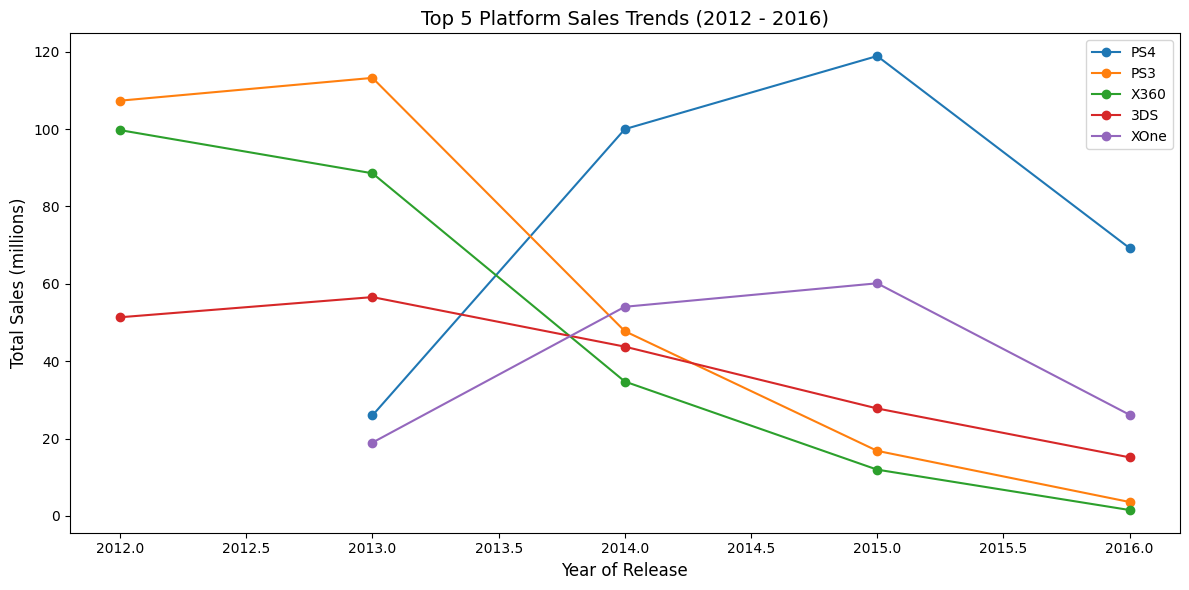

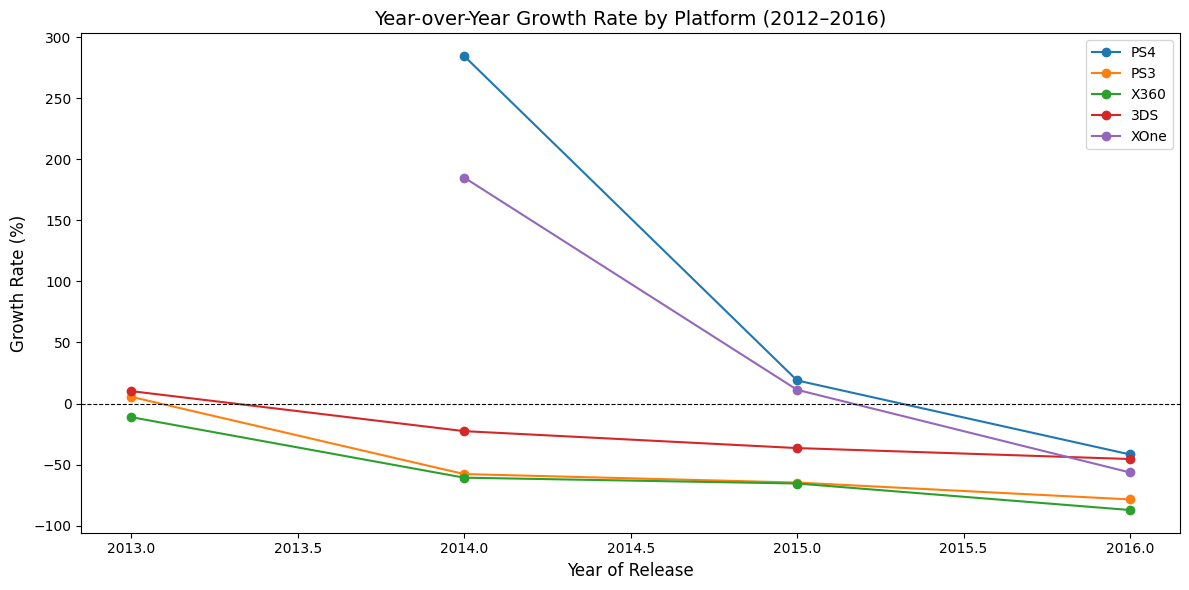

In [23]:
# Visualize top platforms
# Calculate year-over-year growth for each platform
# Your code here to calculate and visualize platform growth rates

top5_yearly['yoy_growth'] = top5_yearly.groupby('platform')['total_sales'].pct_change() * 100
#Plot 1: Total Sales Trends
plt.figure(figsize = (12, 6))
for platform in top5_platforms:
    data = top5_yearly[top5_yearly['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], marker = 'o', label = platform)
plt.title('Top 5 Platform Sales Trends (2012 - 2016)', fontsize = 14)
plt.xlabel('Year of Release', fontsize = 12)
plt.ylabel('Total Sales (millions)', fontsize = 12)
plt.legend()
plt.tight_layout()
plt.show()

#Plot 2: Year-over-Year Growth Rate
plt.figure(figsize=(12, 6))
for platform in top5_platforms:
    data = top5_yearly[top5_yearly['platform'] == platform]
    plt.plot(data['year_of_release'], data['yoy_growth'], marker='o', label=platform)

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)  # zero reference line
plt.title('Year-over-Year Growth Rate by Platform (2012–2016)', fontsize=14)
plt.xlabel('Year of Release', fontsize=12)
plt.ylabel('Growth Rate (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:


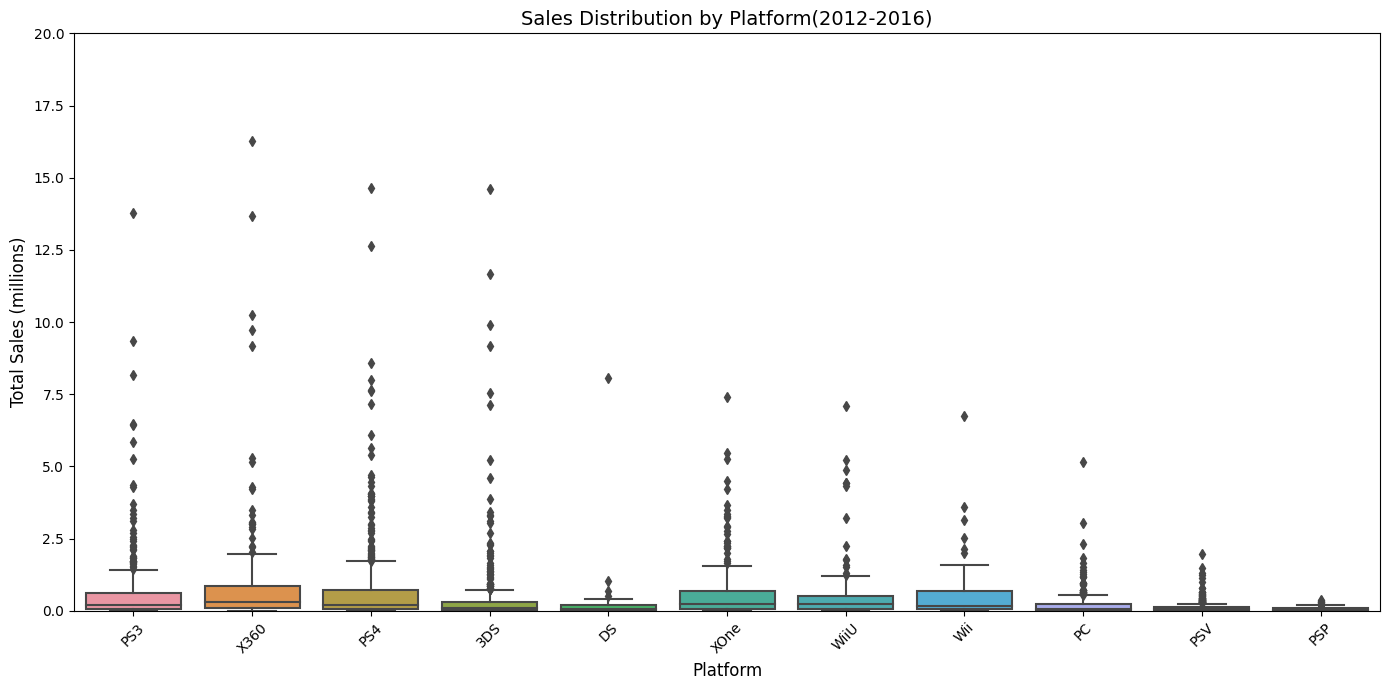

In [24]:
# Create box plot of sales by platform
plt.figure(figsize = (14, 7))
sns.boxplot(
    data = df_relevant,
    x = 'platform',
    y = 'total_sales'
)
plt.ylim(0, 20)
plt.title('Sales Distribution by Platform(2012-2016)', fontsize = 14)
plt.xlabel('Platform', fontsize = 12)
plt.ylabel('Total Sales (millions)', fontsize = 12)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [25]:
# Calculate detailed statistics for each platform
platform_stats = df_relevant.groupby('platform')['total_sales'].describe().round(2).sort_values('mean', ascending = False)
platform_stats

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
X360,292.0,0.81,1.71,0.01,0.10,0.31,0.87,16.27
PS4,392.0,0.80,1.61,0.01,0.06,0.20,0.73,14.63
Wii,54.0,0.65,1.17,0.01,0.06,0.18,0.69,6.76
XOne,247.0,0.65,1.04,0.01,0.06,0.22,0.68,7.39
PS3,493.0,0.59,1.46,0.01,0.05,0.20,0.61,21.05
WiiU,147.0,0.56,1.06,0.01,0.08,0.22,0.52,7.09
3DS,396.0,0.49,1.39,0.01,0.04,0.11,0.31,14.60
DS,31.0,0.40,1.44,0.01,0.02,0.05,0.18,8.06
PC,250.0,0.25,0.49,0.01,0.03,0.08,0.24,5.14


<div class="alert alert-block alert-warning">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

You calculated the boxplot and descriptive stats, but the section is missing the written interpretation answering the prompt (e.g., what the medians/spread/outliers suggest about differences between platforms, and which platforms have meaningfully higher typical sales in your selected period).

</div>



## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:


In [26]:
# Choose a popular platform based on your previous analysis
platform_choice = 'PS4'
df_platform = df_relevant[df_relevant['platform'] == platform_choice].copy()
df_platform.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
42,Grand Theft Auto V,PS4,2014.0,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
77,FIFA 16,PS4,2015.0,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015.0,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,7.98
92,Call of Duty: Advanced Warfare,PS4,2014.0,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66


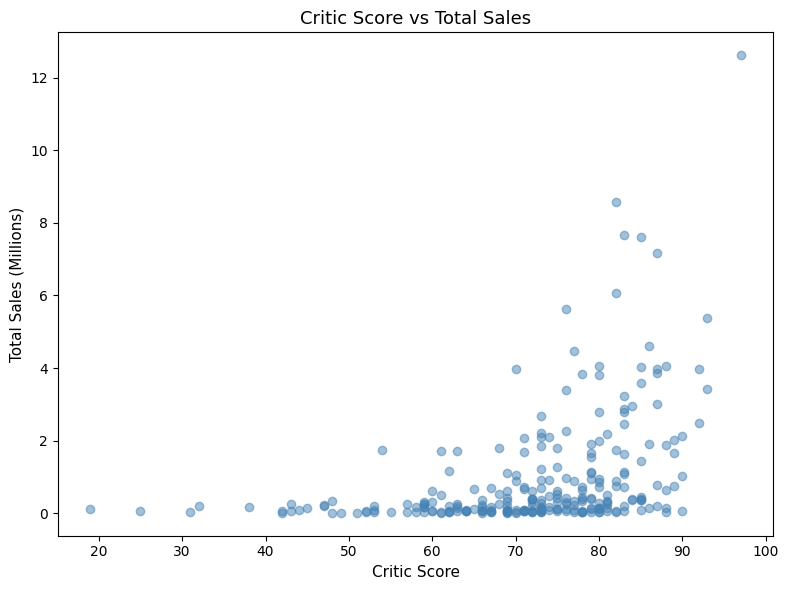

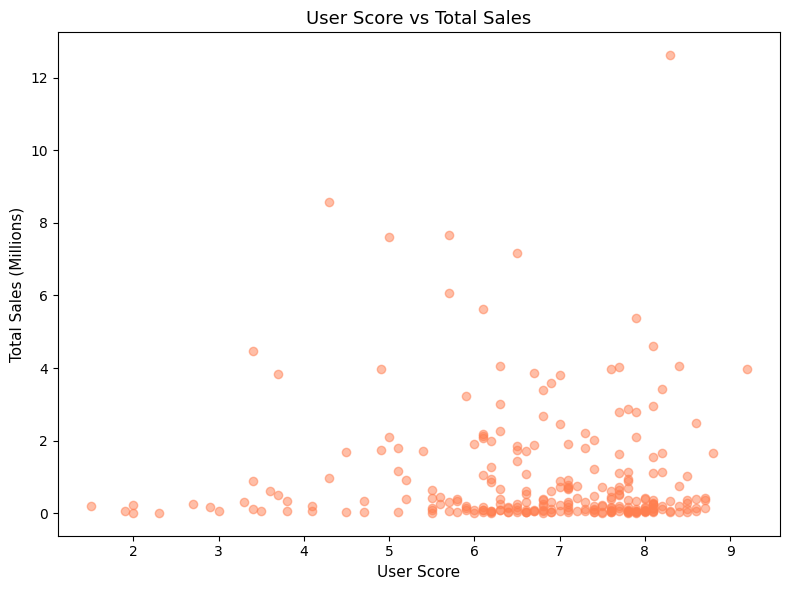

In [27]:
# Create scatter plots for both critic and user scores
#Plot 1: Critic Score vs Total Sales
df_critic = df_platform.dropna(subset = ['critic_score'])
plt.figure(figsize = (8, 6))
plt.scatter(df_critic['critic_score'], df_critic['total_sales'], alpha = 0.5, color = 'steelblue')
plt.title('Critic Score vs Total Sales', fontsize = 13)
plt.xlabel('Critic Score', fontsize = 11)
plt.ylabel('Total Sales (Millions)', fontsize = 11)
plt.tight_layout()
plt.show()

#Plot 2: User Score vs Total Sales
df_user = df_platform.dropna(subset = ['user_score'])
plt.figure(figsize = (8,6))
plt.scatter(df_user['user_score'], df_user['total_sales'], alpha = 0.5, color = 'coral')
plt.title('User Score vs Total Sales', fontsize = 13)
plt.xlabel('User Score', fontsize = 11)
plt.ylabel('Total Sales (Millions)', fontsize = 11)
plt.tight_layout()
plt.show()

In [28]:
# Critic Scores
critic_corr = df_critic['critic_score'].corr(df_critic['total_sales'])


# User Scores
user_corr = df_user['user_score'].corr(df_user['total_sales'])

# Calculate correlations
print(f"Correlarion between Critic Score and Total Sales: {critic_corr:.2f}")
print(f"Correlation between User Score and Total Sales: {user_corr:.2f}")

Correlarion between Critic Score and Total Sales: 0.41
Correlation between User Score and Total Sales: -0.03



## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:


In [29]:
# Find games released on multiple platforms
games_per_platform = df_relevant.groupby('name')['platform'].count()
multi_platform_games = games_per_platform[games_per_platform > 1].index

df_multi = df_relevant[df_relevant['name'].isin(multi_platform_games)].copy()
df_multi.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013.0,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013.0,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
34,Call of Duty: Black Ops II,PS3,2012.0,Shooter,4.99,5.73,0.65,2.42,83.0,5.3,M,13.79
35,Call of Duty: Black Ops II,X360,2012.0,Shooter,8.25,4.24,0.07,1.12,83.0,4.8,M,13.68


<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

When comparing multi-platform performance, averaging by platform can be misleading because each platform may have a different set of multi-platform titles. To compare “the same games across platforms,” consider aligning by game title (and often release year), reshaping to a name×platform table, and then comparing matched sales (e.g., paired differences or distributions across platforms for the same titles).

</div>


<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 2:</b><br>
  The multi-platform comparison currently averages sales by platform for all multi-platform titles. That can be misleading because platforms host different sets of titles. A stronger version of this comparison would align the same games across platforms by reshaping the data so each row is a game and columns are platform sales, for example using a pivot:
  <pre>pivot = df_multi.pivot_table(index='name', columns='platform', values='total_sales')</pre>
  Then compute paired comparisons for titles available on both platforms, for example paired differences between PS4 and XOne for the same game, or a boxplot of per-title differences. This aligned approach gives a fairer comparison and would strengthen the interpretation if you revisit the project.
</div>

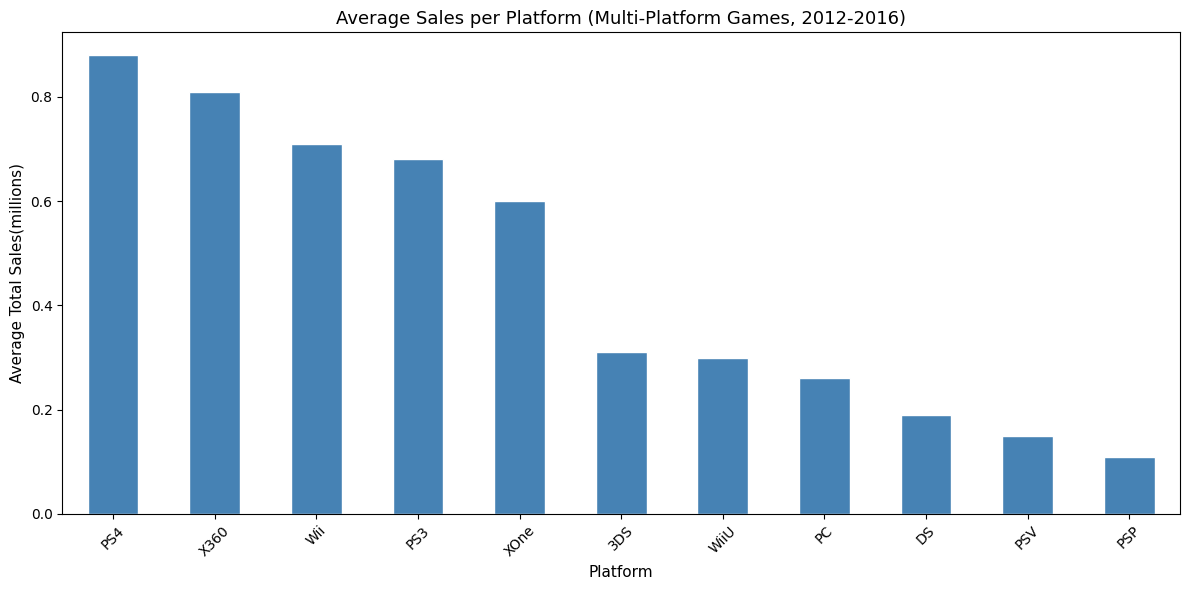

In [30]:
# Compare sales across platforms for these games
# Your code here to analyze and visualize cross-platform performance

platform_comparison = df_multi.groupby('platform')['total_sales'].agg(
    mean_sales = 'mean',
    total_sales = 'sum',
    game_count = 'count'
).round(2).sort_values('mean_sales', ascending = False)

plt.figure(figsize = (12, 6))
platform_comparison['mean_sales'].plot(
    kind = 'bar',
    color = 'steelblue',
    edgecolor = 'white'
)
plt.title('Average Sales per Platform (Multi-Platform Games, 2012-2016)', fontsize = 13)
plt.xlabel('Platform', fontsize = 11)
plt.ylabel('Average Total Sales(millions)', fontsize = 11)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:


In [31]:
# Analyze genre performance
genre_stats = df_relevant.groupby('genre')['total_sales'].agg(
    total_sales = 'sum',
    mean_sales = 'mean',
    game_count = 'count'
).round(2)
genre_stats

,total_sales,mean_sales,game_count
genre,,,
Action,441.12,0.43,1031
Adventure,29.43,0.10,302
Fighting,44.49,0.41,109
Misc,85.04,0.44,192
Platform,61.00,0.72,85
Puzzle,4.89,0.17,28
Racing,53.50,0.47,115
Role-Playing,192.80,0.52,370
Shooter,304.73,1.30,235


In [32]:
# Sort genres by total sales
genre_stats_sorted = genre_stats.sort_values('total_sales', ascending = False)
genre_stats_sorted

,total_sales,mean_sales,game_count
genre,,,
Action,441.12,0.43,1031
Shooter,304.73,1.30,235
Role-Playing,192.80,0.52,370
Sports,181.07,0.68,268
Misc,85.04,0.44,192
Platform,61.00,0.72,85
Racing,53.50,0.47,115
Fighting,44.49,0.41,109
Simulation,35.12,0.44,80


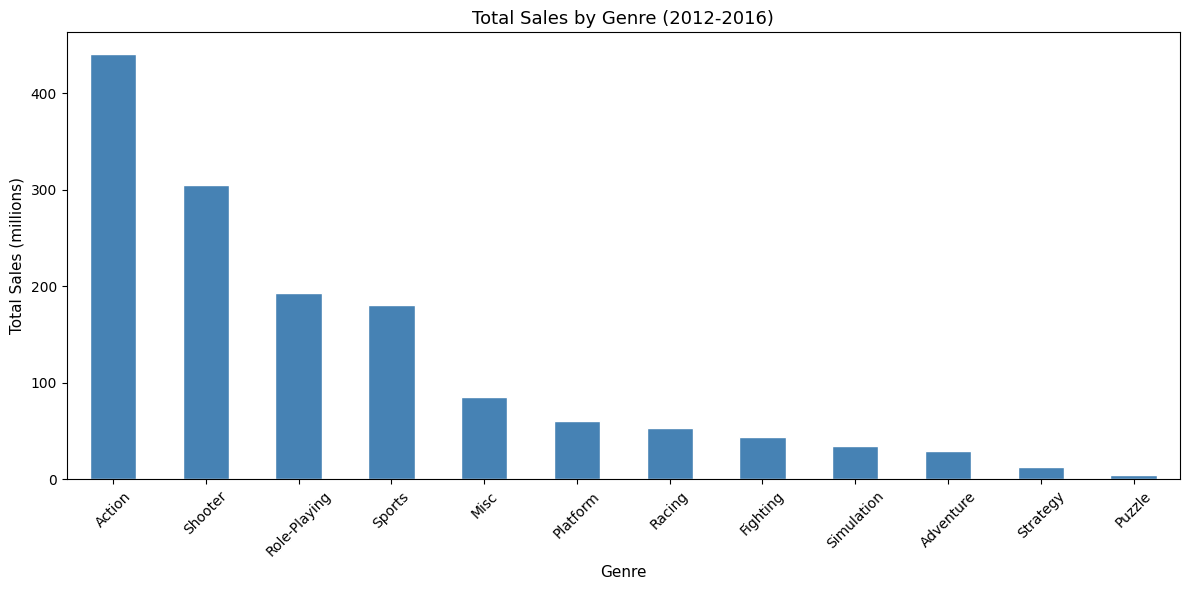

In [33]:
# Visualize genre distribution
plt.figure(figsize = (12, 6))
genre_stats_sorted['total_sales'].plot(
    kind = 'bar',
    color = 'steelblue',
    edgecolor = 'white'
)
plt.title('Total Sales by Genre (2012-2016)', fontsize = 13)
plt.xlabel('Genre', fontsize = 11)
plt.ylabel('Total Sales (millions)', fontsize = 11)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

In [34]:
# Calculate market share for each genre
genre_stats_sorted['market_share'] = (genre_stats_sorted['total_sales'] / genre_stats_sorted['total_sales'].sum() * 100).round(2)

genre_stats_sorted[['total_sales', 'market_share']]

,total_sales,market_share
genre,,
Action,441.12,30.50
Shooter,304.73,21.07
Role-Playing,192.80,13.33
Sports,181.07,12.52
Misc,85.04,5.88
Platform,61.00,4.22
Racing,53.50,3.70
Fighting,44.49,3.08
Simulation,35.12,2.43


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Nice job on the genre analysis: you report total/mean sales and counts, rank genres, visualize the distribution, and compute market share for the selected time window in a clear and consistent way.

</div>



### Key Questions for Genre Analysis:
- Which genres consistently perform well?
Ans: The data reveals a clear hierarchy in genre performance over the 2012–2016 period. Action games dominate the market entirely, generating 441.12M in total sales and commanding a 30.50% market share - meaning nearly one in every three dollars spent on games goes to Action titles. Shooter games follow as a strong second with 304.73M in sales and a 21.07% share, while Role-Playing (192.80M, 13.33%) and Sports (181.07M, 12.52%) round out the top four. Critically, these four genres alone account for 77.4% of all sales in the relevant period, making them the non-negotiable focus for any advertising strategy heading into 2017.


- Are there any genres showing recent growth or decline?
Looking beyond total sales to mean sales per game reveals a more nuanced picture. Shooter is actually the most efficient genre in the dataset - with only 235 games it achieves the highest mean sales of 1.30M per title, suggesting a premium audience willing to spend consistently on quality releases. Action's dominance, by contrast, is largely volume-driven: 1,031 games averaging just 0.43M each. The most concerning pattern belongs to Adventure, which has 302 games - the third highest count - but only averages 0.10M per title, signaling a badly oversaturated genre where most releases fail to find an audience. Strategy and Puzzle show similar warning signs with low counts, low means, and minimal market share, suggesting shrinking rather than growing audiences in the 2012–2016 window.

- How does the average performance vary across genres?
The variation in mean sales across genres is dramatic and arguably the most actionable insight in this entire section. The gap between the best performing genre (Shooter at 1.30M per game) and the worst (Adventure at 0.10M per game) represents a 13x difference in expected returns per title. This means that genre choice alone - independent of platform, review scores, or marketing budget is one of the strongest predictors of whether a game will sell well. Platform games (0.72M mean) and Sports games (0.68M mean) also punch above their weight relative to their market share, suggesting that selective, high-quality releases in these genres can perform very reliably. For Ice store's 2017 advertising strategy, this points clearly toward prioritizing Shooter, Sports, Action and Role-Playing titles, while avoiding heavy investment in Adventure, Strategy and Puzzle games where the probability of a strong return is statistically very low.



# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:



In [35]:
# Function to analyze platform performance by region
def analyze_region_platforms(df, region_col, region_name, top_n = 5):
    region_stats = df.groupby('platform')[region_col].agg(
        total_sales = 'sum',
        mean_sales = 'mean',
        game_count = 'count'
    ).round(2).sort_values('total_sales', ascending = False).head(top_n)
    return region_stats

<div class="alert alert-block alert-danger">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

The regional platform task asks about *market share* differences, not only total sales. Consider adding each platform’s share within each region (platform regional sales divided by total regional sales) and then interpreting how/why the shares differ across NA, EU, and JP.

</div>


<div class="alert alert-warning" style="border-left: 7px solid gold; padding: 5px">
  <b>⚠️ Reviewer’s comment – Iteration 2:</b><br>
  The regional platform task asks for market share differences, not only totals. I recommend computing platform share within each region and adding a short interpretation. For example:
  <pre>region_total = df_relevant['na_sales'].sum()
region_stats['share'] = region_stats['total_sales'] / region_total * 100</pre>
  Doing this for NA, EU, and JP would make it easier to explain why certain platforms have larger shares in one region than another, and it would make the regional analysis more actionable for targeted advertising.
</div>

In [36]:
# Analyze each region
na_platforms = analyze_region_platforms(df_relevant, 'na_sales', 'North America')
eu_platforms = analyze_region_platforms(df_relevant, 'eu_sales', 'Europe')
jp_platforms = analyze_region_platforms(df_relevant, 'jp_sales', 'Japan')


### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:


In [37]:
# Create a comparative platform analysis
platform_comparison = pd.concat([
    na_platforms['total_sales'].rename('NA_sales'),
    eu_platforms['total_sales'].rename('EU_sales'),
    jp_platforms['total_sales'].rename('JP_sales')
], axis = 1).fillna(0)

platform_comparison

,NA_sales,EU_sales,JP_sales
platform,,,
X360,140.05,74.52,0.00
PS4,108.74,141.09,15.96
PS3,103.38,106.86,35.29
XOne,93.12,51.59,0.00
3DS,55.31,42.64,87.79
PSV,0.00,0.00,21.04
WiiU,0.00,0.00,13.01


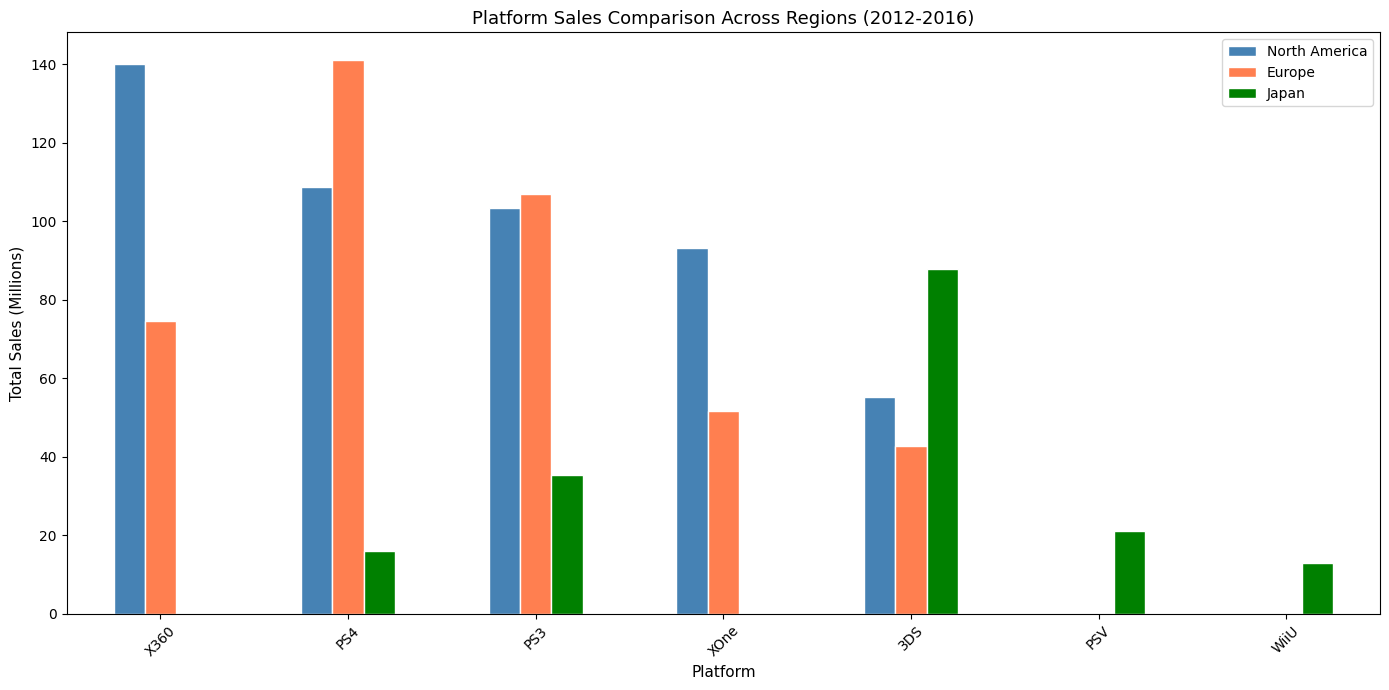

In [38]:
# Visualize cross-regional comparison for top platforms
platform_comparison.plot(
    kind = 'bar',
    figsize = (14, 7),
    color = ['steelblue', 'coral', 'green'],
    edgecolor = 'white'
)
plt.title('Platform Sales Comparison Across Regions (2012-2016)', fontsize = 13)
plt.xlabel('Platform', fontsize = 11)
plt.ylabel('Total Sales (Millions)', fontsize = 11)
plt.legend(['North America', 'Europe', 'Japan'], fontsize = 10)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:


In [39]:
# Function to analyze genre performance by region
def analyze_region_genres(df, region_col, region_name, top_n = 5):
    region_stats = df.groupby('genre')[region_col].agg(
        total_sales = 'sum',
        mean_sales = 'mean',
        game_count = 'count'
    ).round(2).sort_values('total_sales', ascending = False).head(top_n)
    return region_stats
na_genres = analyze_region_genres(df_relevant, 'na_sales', 'North America')
eu_genres = analyze_region_genres(df_relevant, 'eu_sales', 'Europe')
jp_genres = analyze_region_genres(df_relevant, 'jp_sales', 'Japan')

### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

In [40]:
# Create a comparative genre analysis
genre_comparison = pd.concat([
    na_genres['total_sales'].rename('NA_sales'),
    eu_genres['total_sales'].rename('EU_sales'),
    jp_genres['total_sales'].rename('JP_sales')
], axis = 1).fillna(0)

genre_comparison

,NA_sales,EU_sales,JP_sales
genre,,,
Action,177.84,159.34,52.80
Shooter,144.77,113.47,0.00
Sports,81.53,69.09,0.00
Role-Playing,64.00,48.53,65.44
Misc,38.19,0.00,12.86
Racing,0.00,27.29,0.00
Simulation,0.00,0.00,10.41
Fighting,0.00,0.00,9.44


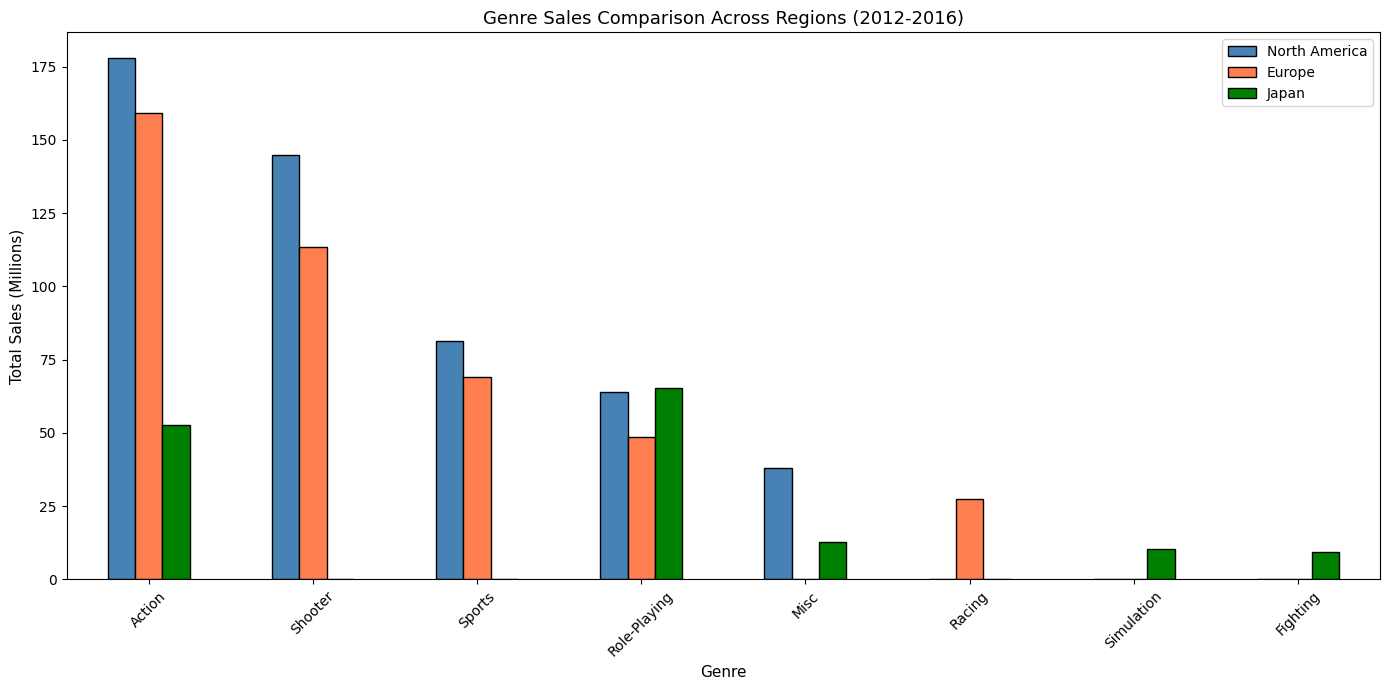

In [41]:
# Visualize cross-regional comparison for top genres
genre_comparison.plot(
    kind = 'bar',
    figsize = (14, 7),
    color = ['steelblue', 'coral', 'green'],
    edgecolor = 'black'
)
plt.title('Genre Sales Comparison Across Regions (2012-2016)', fontsize = 13)
plt.xlabel('Genre', fontsize = 11)
plt.ylabel('Total Sales (Millions)', fontsize = 11)
plt.legend(['North America', 'Europe', 'Japan'], fontsize = 10)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:


In [42]:
# Function to analyze ESRB rating impact
def analyze_region_rating(df, region_col, region_name, top_n = 5):
    region_stats = df.groupby('rating')[region_col].agg(
        total_sales = 'sum',
        mean_sales = 'mean',
        game_count = 'count'
    ).round(2).sort_values('total_sales', ascending = False).head(top_n)
    return region_stats
na_rating = analyze_region_rating(df_relevant, 'na_sales', 'North America')
eu_rating = analyze_region_rating(df_relevant, 'eu_sales', 'Europe')
jp_rating = analyze_region_rating(df_relevant, 'jp_sales', 'Japan')

In [43]:
# Analyze ESRB impact for each region
rating_comparison = pd.concat([
    na_rating['total_sales'].rename('NA_sales'),
    eu_rating['total_sales'].rename('EU_sales'),
    jp_rating['total_sales'].rename('JP_sales')
], axis = 1).fillna(0)

rating_comparison

,NA_sales,EU_sales,JP_sales
rating,,,
M,231.57,193.96,21.20
E,114.37,113.03,28.33
E10+,75.70,55.37,8.19
T,66.02,52.96,26.02


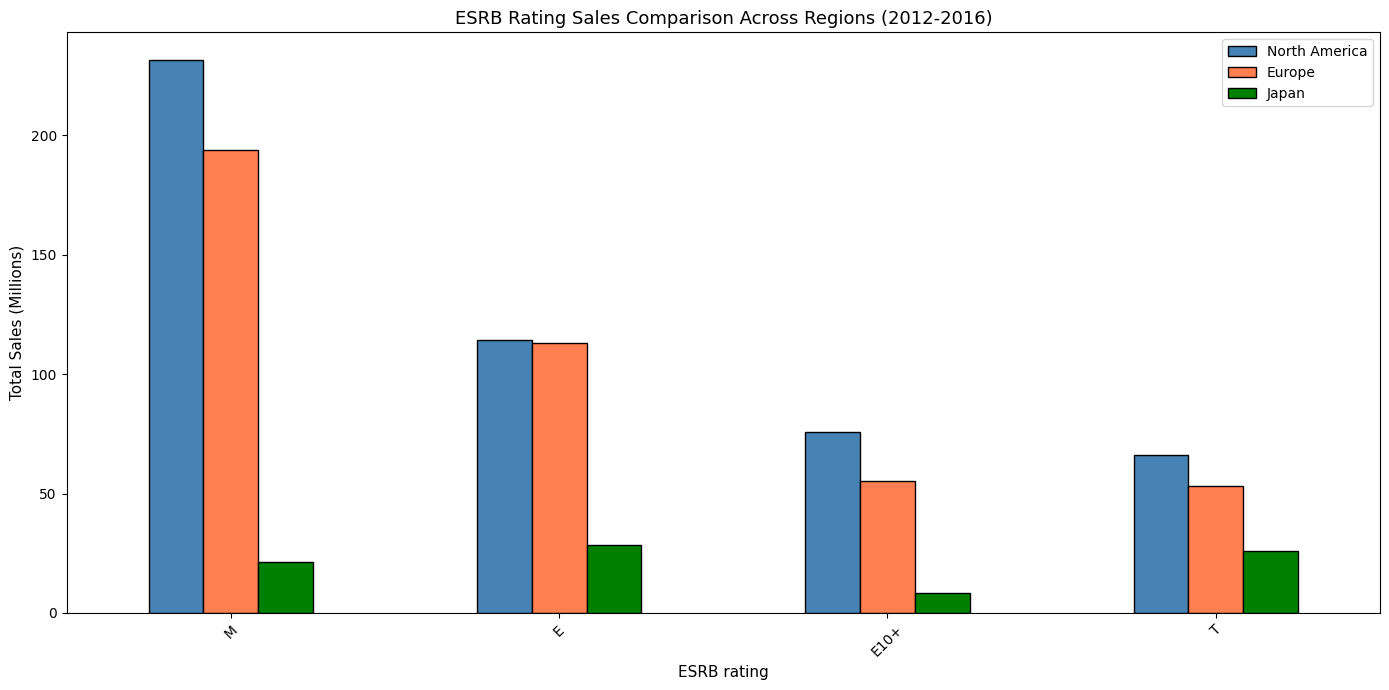

In [44]:
# Visualize cross-regional comparison for top ratings
rating_comparison.plot(
    kind = 'bar',
    figsize = (14, 7),
    color = ['steelblue', 'coral', 'green'],
    edgecolor = 'black'
)
plt.title('ESRB Rating Sales Comparison Across Regions (2012-2016)', fontsize = 13)
plt.xlabel('ESRB rating', fontsize = 11)
plt.ylabel('Total Sales (Millions)', fontsize = 11)
plt.legend(['North America', 'Europe', 'Japan'], fontsize = 10)
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Good completion of the regional analysis: you compare regions for platforms/genres and include an ESRB rating breakdown with clear visualizations to support the comparisons.

</div>



# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses
Ans: Test 1: Xbox One vs PC User Ratings
- H₀ (null): The average user rating for Xbox One = average user rating for PC.
- H₁ (alternative): The average user rating for Xbox One != average user rating for PC.
- This is a two-tailed test because we're asking if they're different in EITHER direction.

Test 2: Action vs Sports User Ratings
- H₀ (null): The average user rating for Action games = average user rating for Sports games.
- H₁ (alternative): The average user rating for Action games != average user rating for Sports games.
- Two-tailed again - we don't assume which genre rates higher beforehand.

—What criteria you used to test the hypotheses~~,~~ and why
Ans: We used a two-sample independent t-test (scipy.stats.ttest_ind) because:
- We're comparing means of two independent groups.
- User score is a continuous numeric variable.
- The two groups don't overlap (XOne users != PC users).
- We don't know the true population standard deviation.

Alpha threshold set at a = 0.05 - the standard significance level, accepting a 5% chance of incorrectly rejecting H₀.

In [45]:
alpha = 0.05
# TEST 1: Xbox One vs PC - Average User Ratings
xone_scores = df_relevant[df_relevant['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df_relevant[df_relevant['platform'] == 'PC']['user_score'].dropna()

results = st.ttest_ind(xone_scores, pc_scores)
print('p-value: ', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

# TEST 2: Action vs Sports - Average User Ratings
action_scores = df_relevant[df_relevant['genre'] == 'Action']['user_score'].dropna()
sports_scores = df_relevant[df_relevant['genre'] == 'Sports']['user_score'].dropna()

results = st.ttest_ind(action_scores, sports_scores)
print('p-value: ', results.pvalue)
if results.pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis")

p-value:  0.5535080500643661
We can't reject the null hypothesis
p-value:  3.7163089460934874e-26
We reject the null hypothesis


<div class="alert alert-block alert-success">
<b>Reviewer's comment, Iteration 1</b> <a class="tocSkip"></a>

Your hypothesis testing workflow is solid: you define alpha, handle missing values with `dropna()`, use an appropriate two-sample t-test, and your conclusions correctly follow from the p-values.

</div>


# Step 6. Write a general conclusion


### Project Overview
This analysis examined 16,715 video game records to identify patterns driving sales success for the Ice online store's 
2017 advertising strategy. The relevant analysis window was 
narrowed to 2012–2016 to reflect current market conditions.

### Key Findings

#### 1. Platform Recommendations
PS4 is the strongest platform for 2017 advertising:
- Highest total sales in 2012–2016 (314.14M)
- Current-gen with growing user base
- Healthy mean sales (0.80M per game)

Platforms to avoid investing in:
- PSP, PSV - low sales ceilings
- Wii, PS3, X360 - 5 consecutive years of decline post-2012

#### 2. Genre Recommendations
Four genres dominate 77.4% of all sales:
- Action     30.50% market share (1,031 games)
- Shooter    21.07% market share (highest mean: 1.30M/game)
- Role-Playing 13.33% market share
- Sports     12.52% market share

Shooter is the most efficient genre - fewer releases 
but highest average sales per game. Action dominates 
by volume. Both are strong advertising targets.

Genres to avoid: Adventure (0.10M mean), 
Puzzle (0.34% market share), Strategy (0.92%)

#### 3. Regional Differences
Markets behave very differently across regions:
- North America - PS4 and XOne dominate, Action/Shooter lead
- Europe        - PS4 strongly preferred, similar genre tastes to NA
- Japan         - 3DS dominates, handheld preference is strong,
                  XOne has near-zero presence

A single global advertising strategy would be ineffective,
regional campaigns are strongly recommended.

#### 4. Review Score Impact
Critic scores show moderate positive correlation with sales.
User scores show a weaker relationship.
Professional reviews matter more than user reviews 
for predicting commercial success.

#### 5. Hypothesis Test Results
- Xbox One vs PC user ratings: NO significant difference
  (p=0.55) — user satisfaction is consistent across platforms
  
- Action vs Sports user ratings: SIGNIFICANT difference  
  (p=3.7e-26) - these genres attract genuinely different 
  audiences with different expectations

### Limitations
- 2016 data is underreported due to sales reporting lag
- Digital sales (Steam, PSN, App Store) are not captured,
  meaning PC and mobile market shares are understated
- Score data is missing for 50% of games, limiting 
  the reliability of correlation analysis
- Dataset covers up to 2016 only, market may have 
  shifted further by 2017